# Time Delays

In [1]:
%matplotlib inline
%config IPython.matplotlib.backend = "retina"
from matplotlib import rcParams
rcParams["figure.dpi"] = 150
rcParams["savefig.dpi"] = 150

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk

from astropy.timeseries import LombScargle
from timedelay import TimeDelay
from timedelay.estimator import estimate_frequencies

/Users/shanekomeiji/miniforge3/envs/AstronomicalData/lib/python3.14/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [84]:
target = "TIC 395172881"

search = lk.search_lightcurve(
    target,
    author="QLP"
)

lc_collection = search.download_all(quality_bitmask='hardest')

print(f"Number of downloaded light curves: {len(lc_collection)}")

all_times = []
all_fluxes = []

for lc in lc_collection:
    lc = lc.normalize().remove_nans().remove_outliers()

    sector_time = np.asarray(lc.time.value, dtype=float)
    sector_flux = np.asarray(lc.flux.value, dtype=float)

    mask = np.isfinite(sector_time) & np.isfinite(sector_flux)
    sector_time = sector_time[mask]
    sector_flux = sector_flux[mask]

    sector_flux = sector_flux - np.nanmedian(sector_flux)

    all_times.append(sector_time)
    all_fluxes.append(sector_flux)

all_time = np.concatenate(all_times)
all_flux = np.concatenate(all_fluxes)

order = np.argsort(all_time)
all_time = all_time[order]
all_flux = all_flux[order]

freqs = estimate_frequencies(
    all_time,
    all_flux,
    fmin=5.0,
    fmax=75.0,
    max_peaks=5,
    oversample=4.0,
    optimize_f=True
)

print("Global frequencies:", freqs)

Number of downloaded light curves: 4
Global frequencies: [22.2143527  22.23171972 22.19882649 22.91868857 18.96158819]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 24264/24264 [00:00<00:00, 1788995.59it/s]


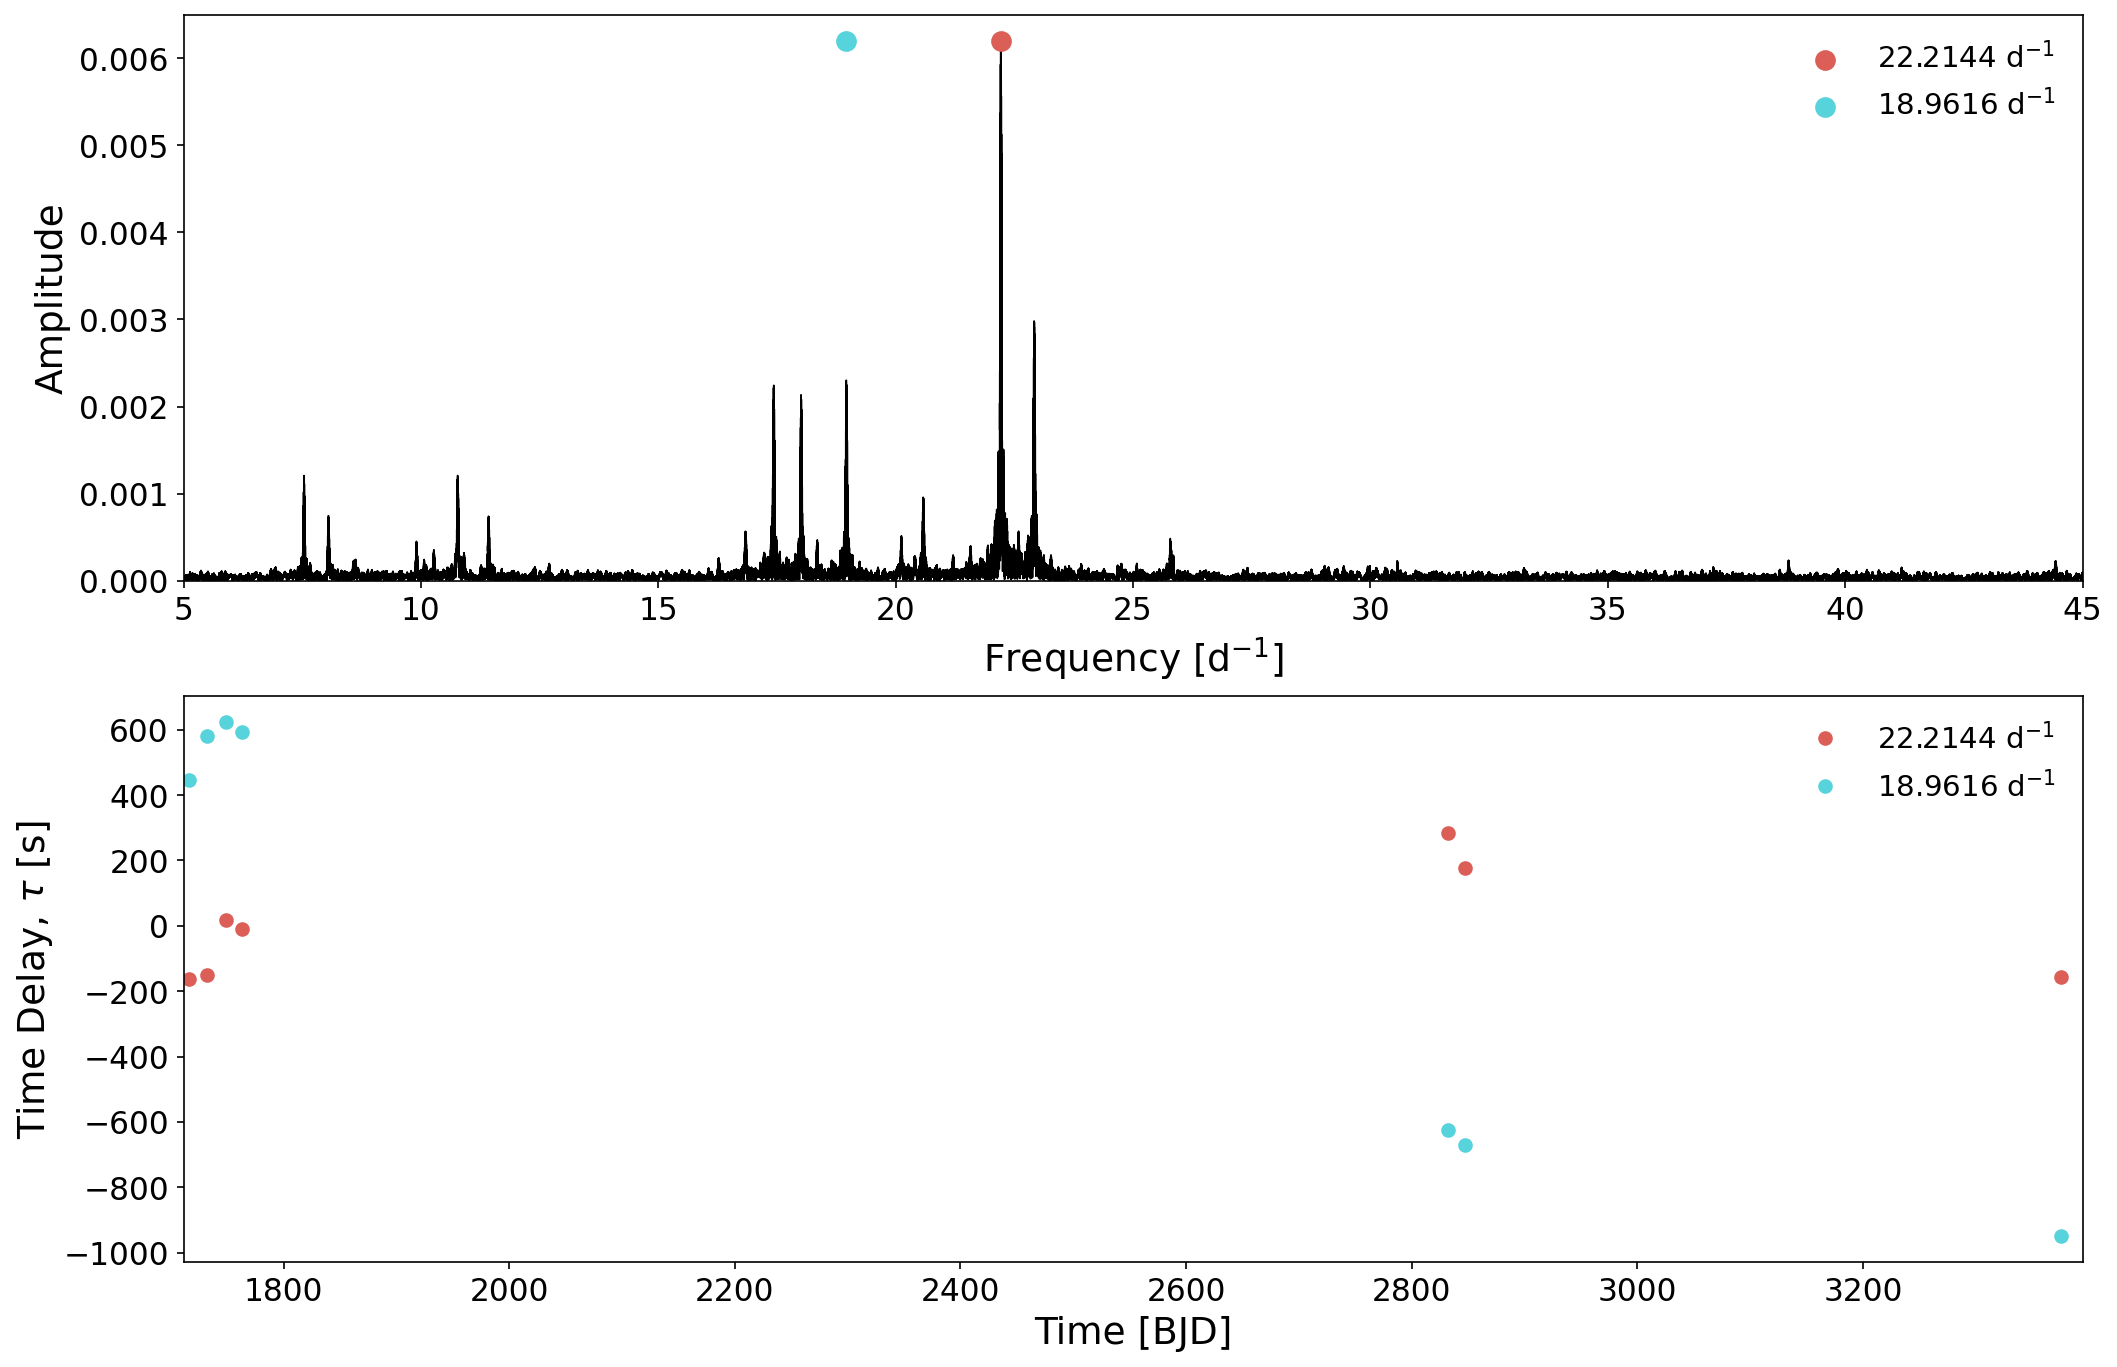

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# Import TimeDelay however you normally import it
from timedelay import TimeDelay


# ======================================================
# Create the TimeDelay object
# ======================================================

td = TimeDelay(
    all_time,
    all_flux,
    freqs=[22.2143527, 18.96158819],
    fmin=5.0,
    fmax=45.0,
)


# ======================================================
# Settings
# ======================================================

segment_size = 15

label_fontsize = 18
tick_fontsize = 15
legend_fontsize = 14
title_fontsize = 18

figsize = (14, 9)


# ======================================================
# Calculate the time delays
# ======================================================

time_midpoints, time_delays = td.time_delay(
    segment_size=segment_size
)

time_midpoints = np.asarray(
    time_midpoints,
    dtype=float
)

time_delays = np.asarray(
    time_delays,
    dtype=float
)


# ======================================================
# Calculate the power spectrum
# ======================================================

periodogram_freq, periodogram_amp = td.periodogram()

periodogram_freq = np.asarray(
    periodogram_freq,
    dtype=float
)

periodogram_amp = np.asarray(
    periodogram_amp,
    dtype=float
)


# ======================================================
# Use the same colors as td.first_look()
# ======================================================

colors = td.unique_colors(
    len(time_delays)
)


# ======================================================
# Create the two-panel figure
# ======================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=figsize,
    constrained_layout=True
)

ax_periodogram = axes[0]
ax_time_delay = axes[1]


# ======================================================
# Top panel: Power spectrum
# ======================================================

ax_periodogram.plot(
    periodogram_freq,
    periodogram_amp,
    color="black",
    linewidth=0.8
)

# Mark each frequency used in the time-delay calculation
for freq, color in zip(td.freqs, colors):
    ax_periodogram.scatter(
        freq,
        np.max(periodogram_amp),
        color=color,
        s=80,
        zorder=5,
        label=rf"{freq:.4f} d$^{{-1}}$"
    )

ax_periodogram.set_xlim(
    periodogram_freq[0],
    periodogram_freq[-1]
)

ax_periodogram.set_ylim(
    0,
    None
)

ax_periodogram.set_xlabel(
    r"Frequency [d$^{-1}$]",
    fontsize=label_fontsize
)

ax_periodogram.set_ylabel(
    "Amplitude",
    fontsize=label_fontsize
)

ax_periodogram.tick_params(
    axis="both",
    labelsize=tick_fontsize
)

ax_periodogram.legend(
    fontsize=legend_fontsize,
    frameon=False
)


# ======================================================
# Bottom panel: Time delays
# ======================================================

for freq, delay, color in zip(
    td.freqs,
    time_delays,
    colors
):
    ax_time_delay.plot(
        time_midpoints,
        delay,
        marker="o",
        linestyle="None",
        markersize=6,
        linewidth=1.5,
        color=color,
        label=rf"{freq:.4f} d$^{{-1}}$"
    )

ax_time_delay.set_xlim(
    np.min(all_time),
    np.max(all_time)
)

ax_time_delay.set_xlabel(
    "Time [BJD]",
    fontsize=label_fontsize
)

ax_time_delay.set_ylabel(
    r"Time Delay, $\tau$ [s]",
    fontsize=label_fontsize
)

ax_time_delay.tick_params(
    axis="both",
    labelsize=tick_fontsize
)

ax_time_delay.legend(
    fontsize=legend_fontsize,
    frameon=False
)


# ======================================================
# Display the figure
# ======================================================

plt.show()

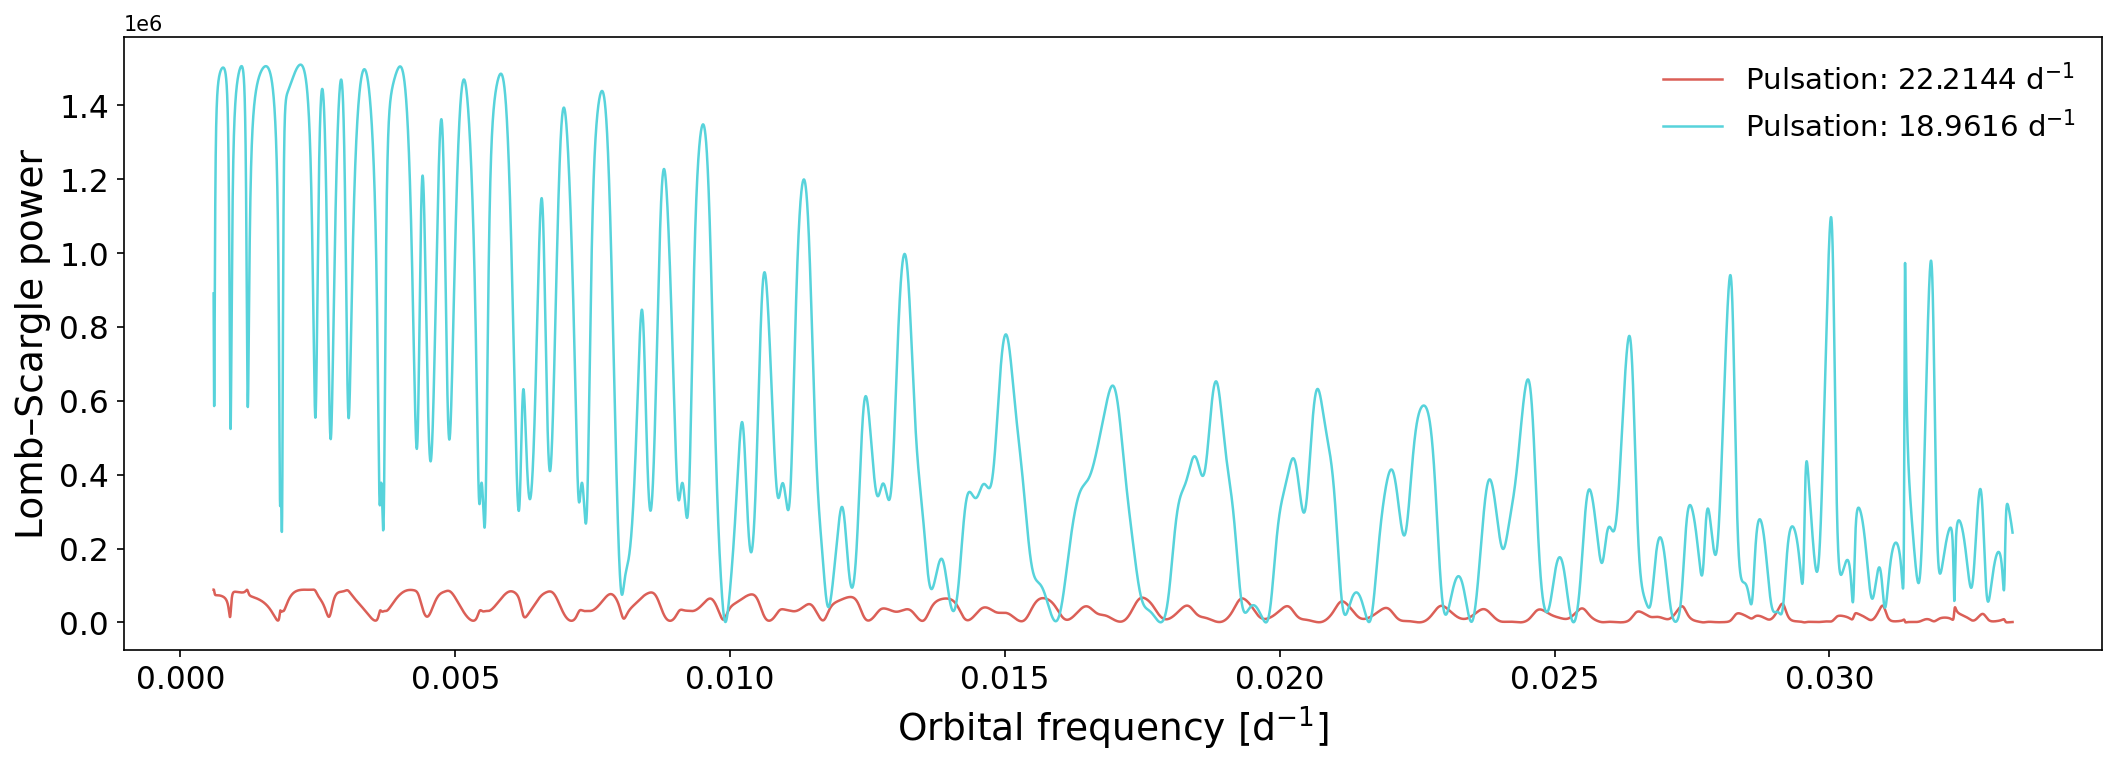

In [86]:
time_midpoints = np.asarray(time_midpoints, dtype=float)
time_delays = np.asarray(time_delays, dtype=float)

# Total time covered by the time-delay measurements
baseline = np.ptp(time_midpoints)

# Search periods from roughly twice the segment size
min_period = 2 * segment_size
max_period = baseline

min_orbital_frequency = 1.0 / max_period
max_orbital_frequency = 1.0 / min_period

td_frequency = np.linspace(
    min_orbital_frequency,
    max_orbital_frequency,
    100_000
)

fig, ax = plt.subplots(
    figsize=(14, 5),
    constrained_layout=True
)

td_powers = []

for freq, delay, color in zip(
    td.freqs,
    time_delays,
    colors
):
    mask = (
        np.isfinite(time_midpoints)
        & np.isfinite(delay)
    )

    times_valid = time_midpoints[mask]
    delays_valid = delay[mask]

    # Remove the mean time delay
    delays_valid = delays_valid - np.mean(delays_valid)

    ls = LombScargle(
        times_valid,
        delays_valid,
        center_data=True
    )

    power = ls.power(
        td_frequency,
        normalization="psd"
    )

    td_powers.append(power)

    ax.plot(
        td_frequency,
        power,
        color=color,
        linewidth=1.2,
        label=rf"Pulsation: {freq:.4f} d$^{{-1}}$"
    )

ax.set_xlabel(
    r"Orbital frequency [d$^{-1}$]",
    fontsize=label_fontsize
)

ax.set_ylabel(
    "Lomb–Scargle power",
    fontsize=label_fontsize
)

ax.tick_params(
    axis="both",
    labelsize=tick_fontsize
)

ax.legend(
    fontsize=legend_fontsize,
    frameon=False
)

plt.show()

In [87]:
mean_td_power = np.nanmean(
    np.asarray(td_powers),
    axis=0
)

peak_index = np.nanargmax(mean_td_power)

peak_frequency = td_frequency[peak_index]
period_bound = 1.0 / peak_frequency

print(f"Peak frequency: {peak_frequency:.8f} d^-1")
print(f"Bound on orbital period: {period_bound:.2f} days")

Peak frequency: 0.00218743 d^-1
Bound on orbital period: 457.16 days


100%|██████████████████████████████████████████████████████████████████████████████████████████| 40086/40086 [00:00<00:00, 2465472.10it/s]


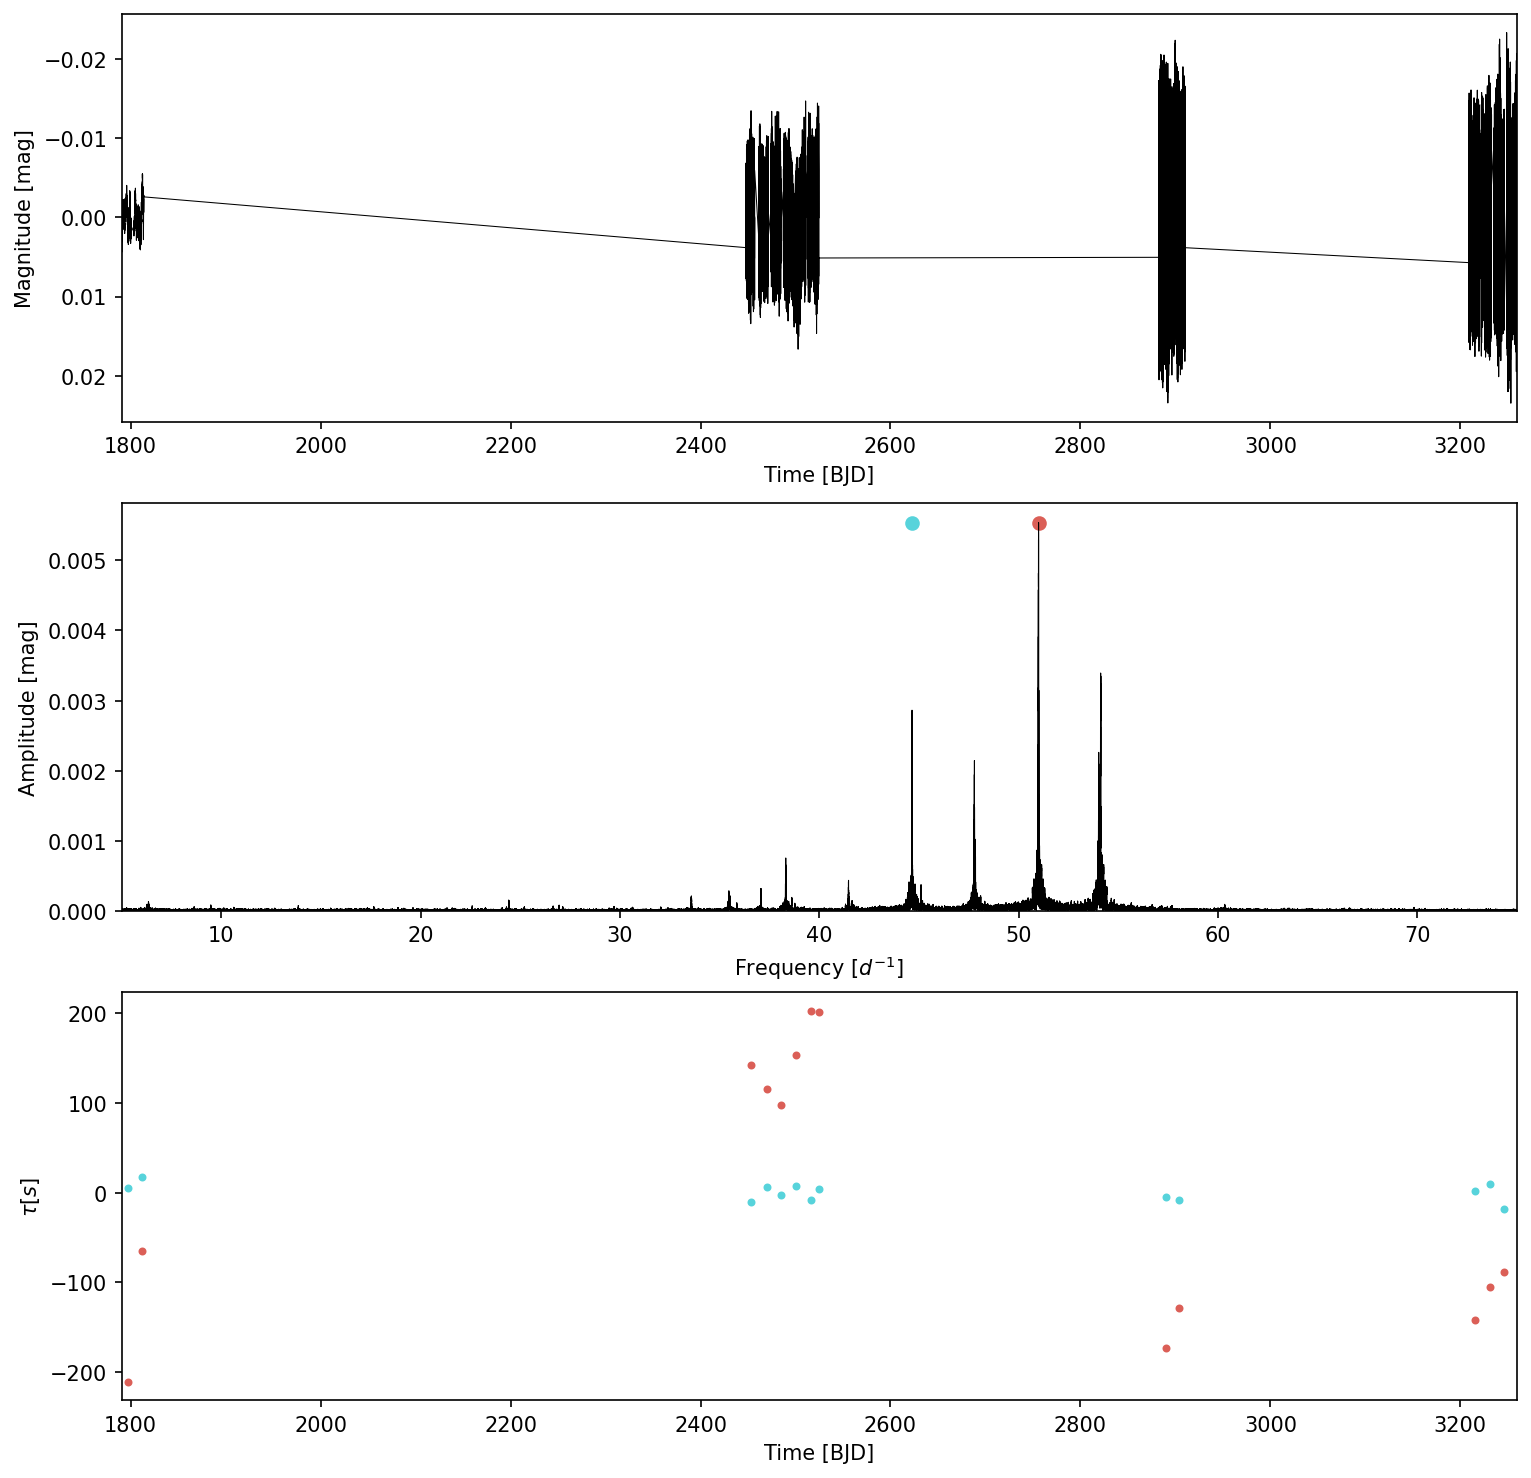

In [116]:
td = TimeDelay(
    all_time,
    all_flux,
    freqs=[51.00239466, 44.65579934],
    fmin=5.0,
    fmax=75.0,
)

td.first_look(segment_size=15)

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 977.03it/s]


<Axes: xlabel='Time [BJD]', ylabel='Time delay (s)'>

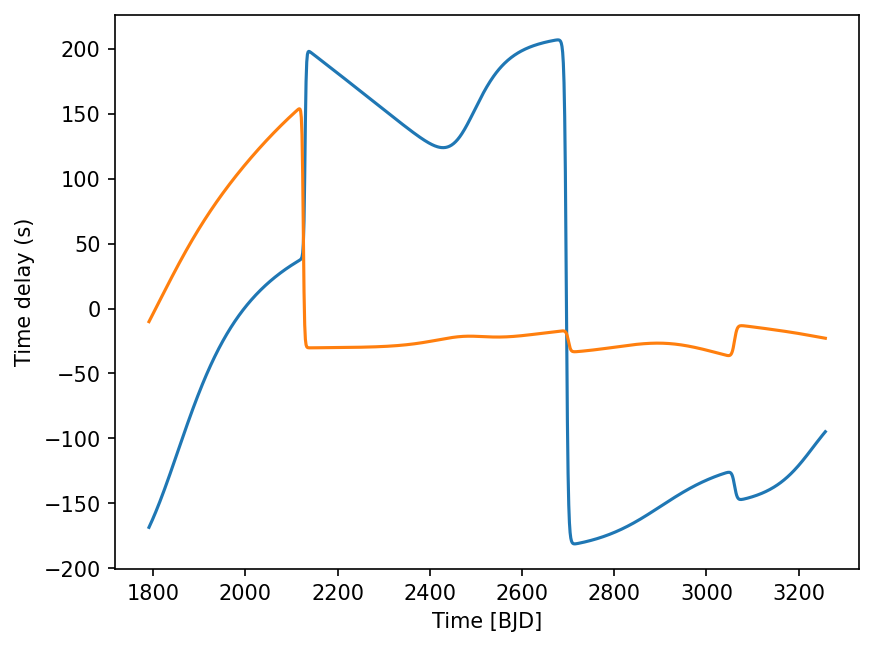

In [117]:
td.plot_wavelet_td(windows=1000, gwidth=30)

51.002395 d^-1  amplitude = 0.00553786
44.655799 d^-1  amplitude = 0.00278614


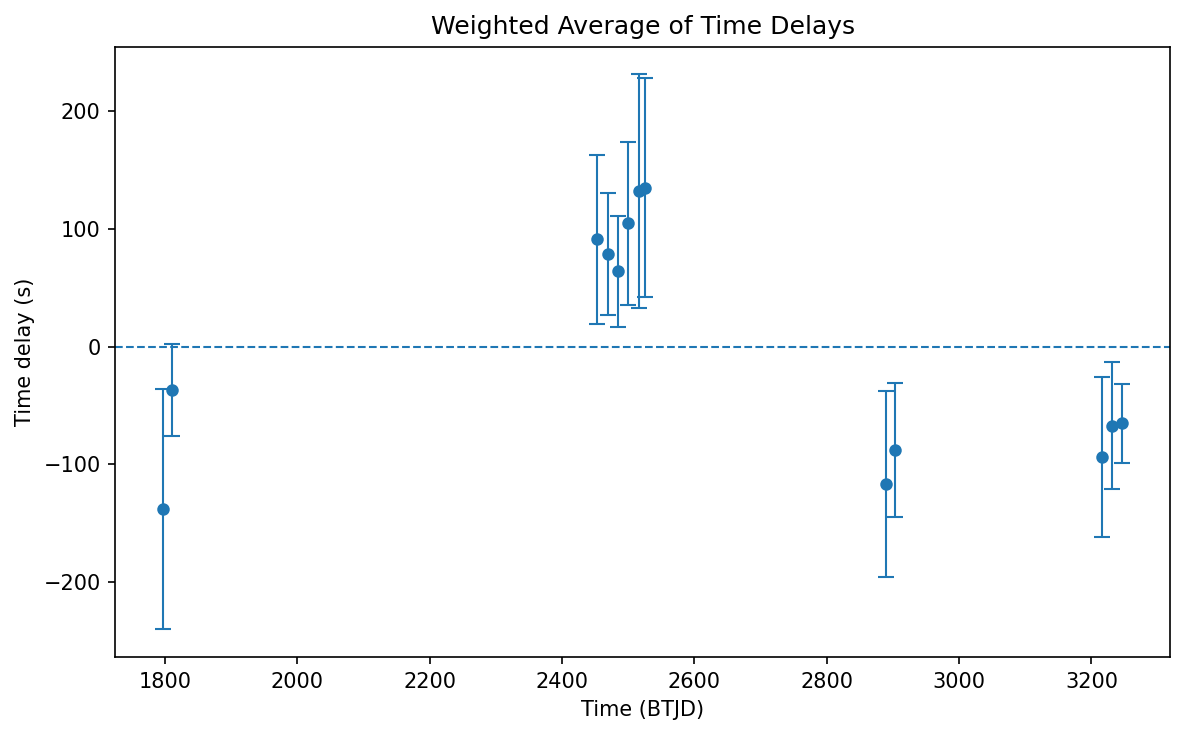

In [118]:
tau = np.asarray(td.time_delays, dtype=float)
freqs = np.asarray(td.freqs, dtype=float)

per_freq, per_amp = td.periodogram()

amplitudes = []

for f in freqs:
    idx = np.argmin(np.abs(per_freq - f))
    print(f"{f:.6f} d^-1  amplitude = {per_amp[idx]:.6g}")
    amplitudes.append(per_amp[idx])

amplitudes = np.asarray(amplitudes, dtype=float)

weights = amplitudes / np.sum(amplitudes)

tau_weighted = np.average(
    tau,
    axis=0,
    weights=weights
)

tau_weighted_variance = np.average(
    (tau - tau_weighted[np.newaxis, :])**2,
    axis=0,
    weights=weights
)

tau_weighted_std = np.sqrt(tau_weighted_variance)

time_midpoints = np.asarray(td.time_midpoints, dtype=float)

plt.figure(figsize=(8, 5))

plt.errorbar(
    time_midpoints,
    tau_weighted,
    yerr=tau_weighted_std,
    fmt="o",
    capsize=4,
    elinewidth=1,
    markersize=5
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Time (BTJD)")
plt.ylabel("Time delay (s)")
plt.title("Weighted Average of Time Delays")
plt.tight_layout()
plt.show()

38.5124370468313


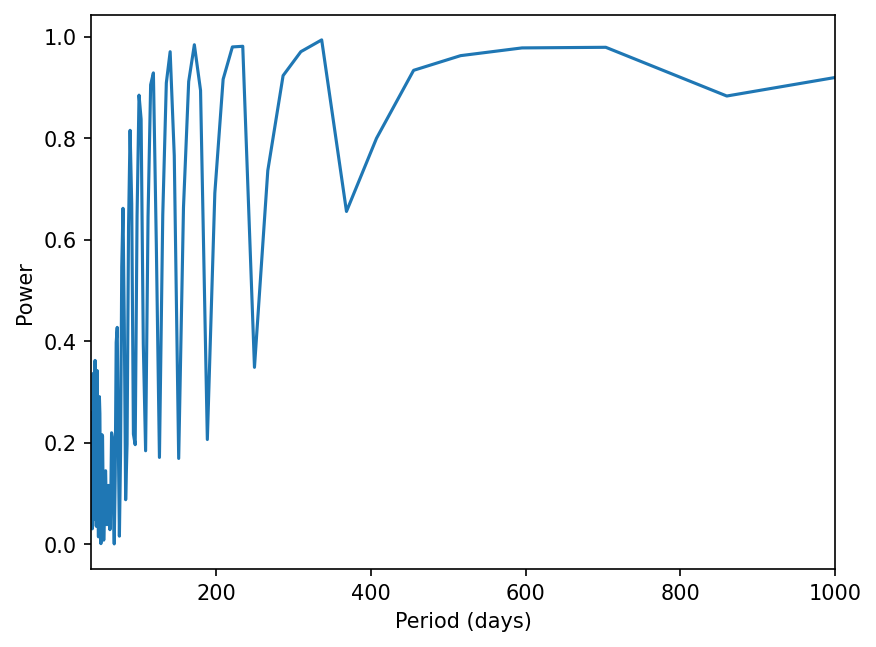

In [16]:
freq, power = LombScargle(td.time_midpoints, tau_weighted).autopower()
period = 1 / freq

sort_idx = np.argsort(period)

min_period = 1 / np.max(freq)
print(min_period)

plt.plot(period[sort_idx], power[sort_idx])
plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.xlim(min_period, 1000)
plt.show()

# Rotational splitting of modes

In [1]:
%matplotlib inline
%config IPython.matplotlib.backend = "retina"
from matplotlib import rcParams
rcParams["figure.dpi"] = 150
rcParams["savefig.dpi"] = 150

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk

from astropy.timeseries import LombScargle
from timedelay import TimeDelay
from timedelay.estimator import estimate_frequencies

/Users/shanekomeiji/miniforge3/envs/AstronomicalData/lib/python3.14/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [55]:
target = "TIC 430006517"
sector = 84

search = lk.search_lightcurve(
    target,
    author="QLP",
    sector=sector
)

lc = search.download(quality_bitmask="hardest")

lc = lc.normalize().remove_nans().remove_outliers()

time = np.asarray(lc.time.value, dtype=float)
flux = np.asarray(lc.flux.value, dtype=float)

mask = np.isfinite(time) & np.isfinite(flux)
time = time[mask]
flux = flux[mask]

flux = flux - np.nanmedian(flux)

freqs = estimate_frequencies(
    time,
    flux,
    fmin=5.0,
    fmax=75.0,
    max_peaks=5,
    oversample=4.0,
    optimize_f=True
)

print("Frequencies:", freqs)

Frequencies: [62.2696172  58.89698298  5.16852223  6.18284462  7.29469549]


In [67]:
target = "TIC 332914217"

search = lk.search_lightcurve(
    target,
    author="QLP"
)

lc_collection = search.download_all(quality_bitmask='hardest')

print(f"Number of downloaded light curves: {len(lc_collection)}")

all_times = []
all_fluxes = []

for lc in lc_collection:
    lc = lc.normalize().remove_nans().remove_outliers()

    sector_time = np.asarray(lc.time.value, dtype=float)
    sector_flux = np.asarray(lc.flux.value, dtype=float)

    mask = np.isfinite(sector_time) & np.isfinite(sector_flux)
    sector_time = sector_time[mask]
    sector_flux = sector_flux[mask]

    sector_flux = sector_flux - np.nanmedian(sector_flux)

    all_times.append(sector_time)
    all_fluxes.append(sector_flux)

all_time = np.concatenate(all_times)
all_flux = np.concatenate(all_fluxes)

order = np.argsort(all_time)
all_time = all_time[order]
all_flux = all_flux[order]

freqs = estimate_frequencies(
    all_time,
    all_flux,
    fmin=5.0,
    fmax=75.0,
    max_peaks=5,
    oversample=4.0,
    optimize_f=True
)

print("Global frequencies:", freqs)

Number of downloaded light curves: 3
Global frequencies: [23.22969523 23.2200483  17.58902115 23.23968872 17.57946883]


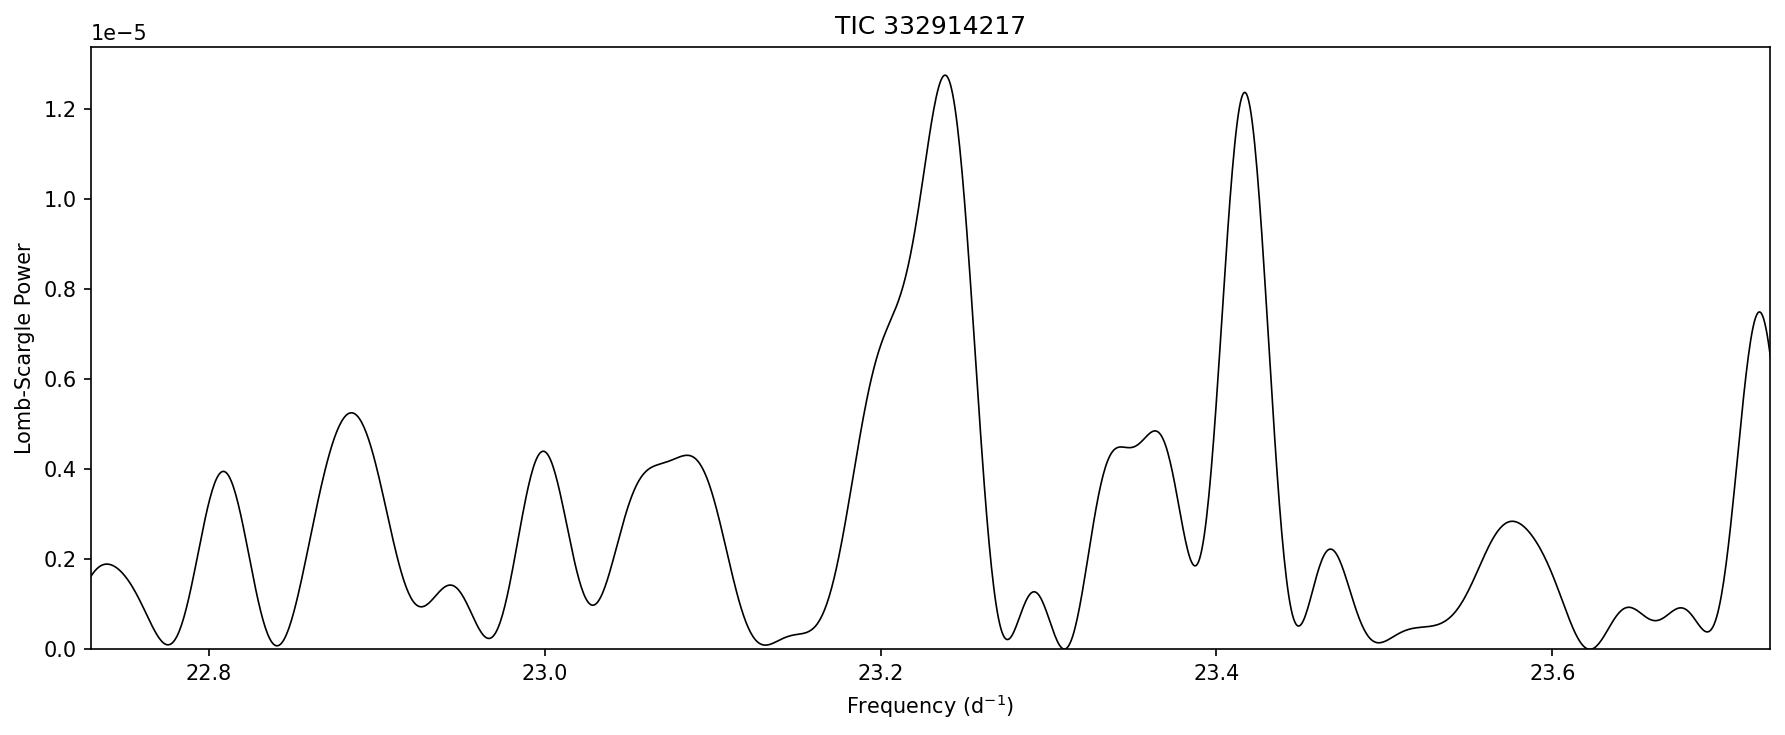

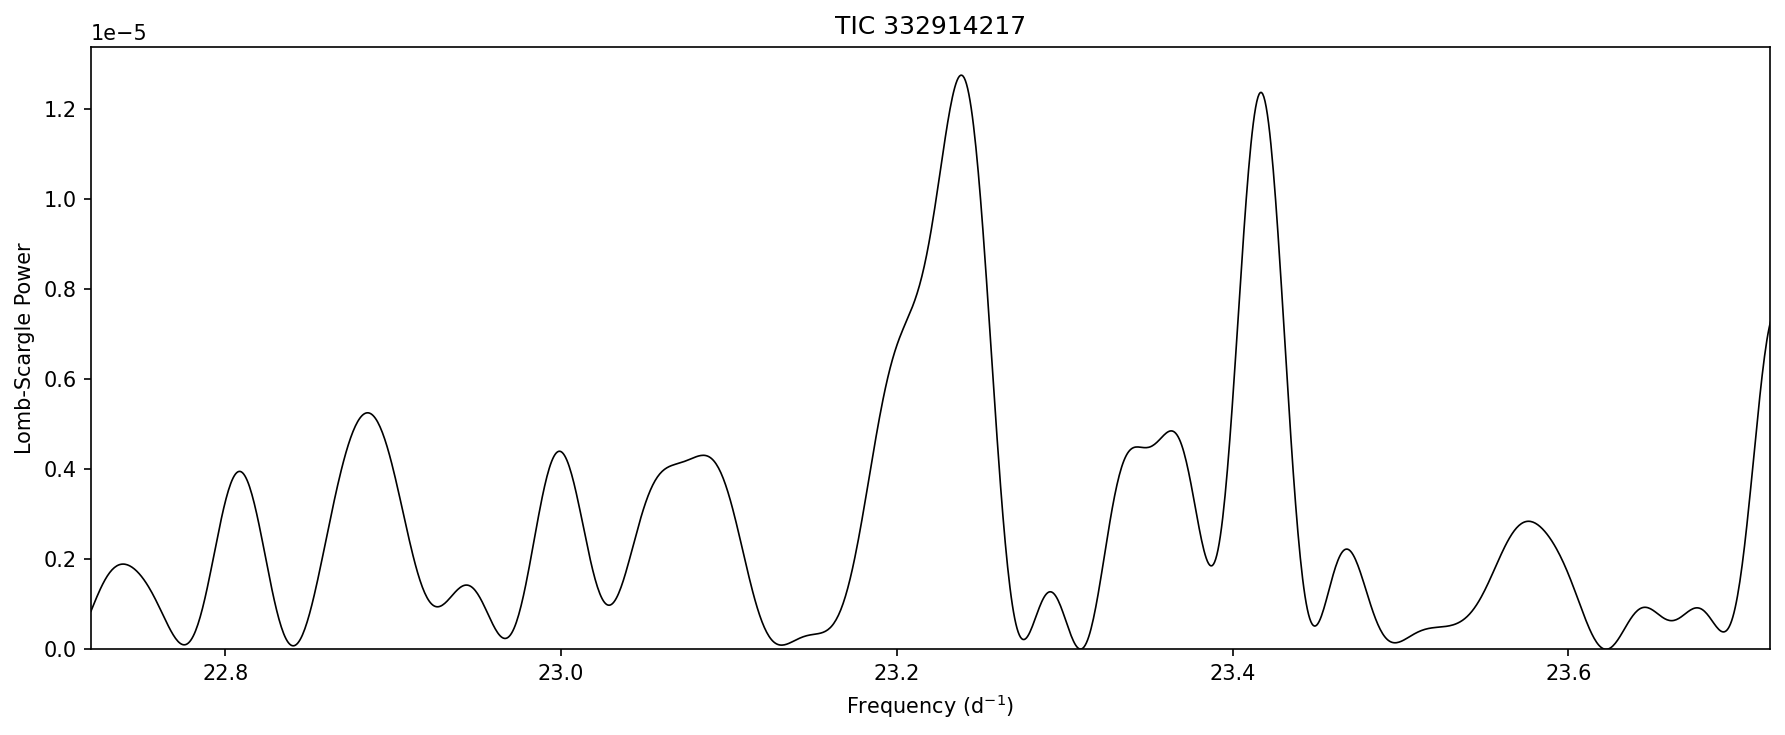

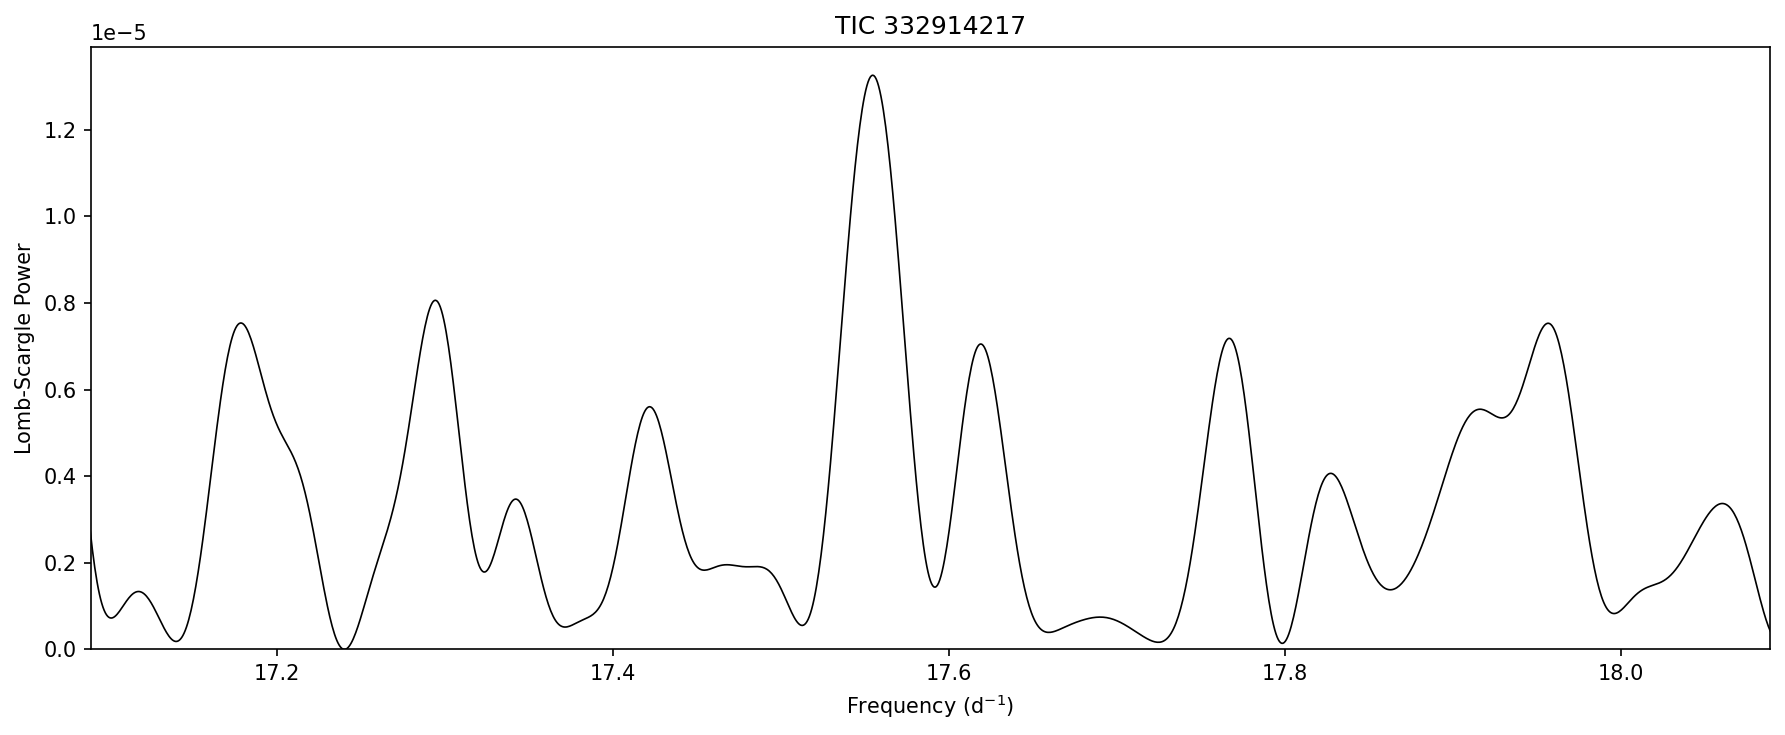

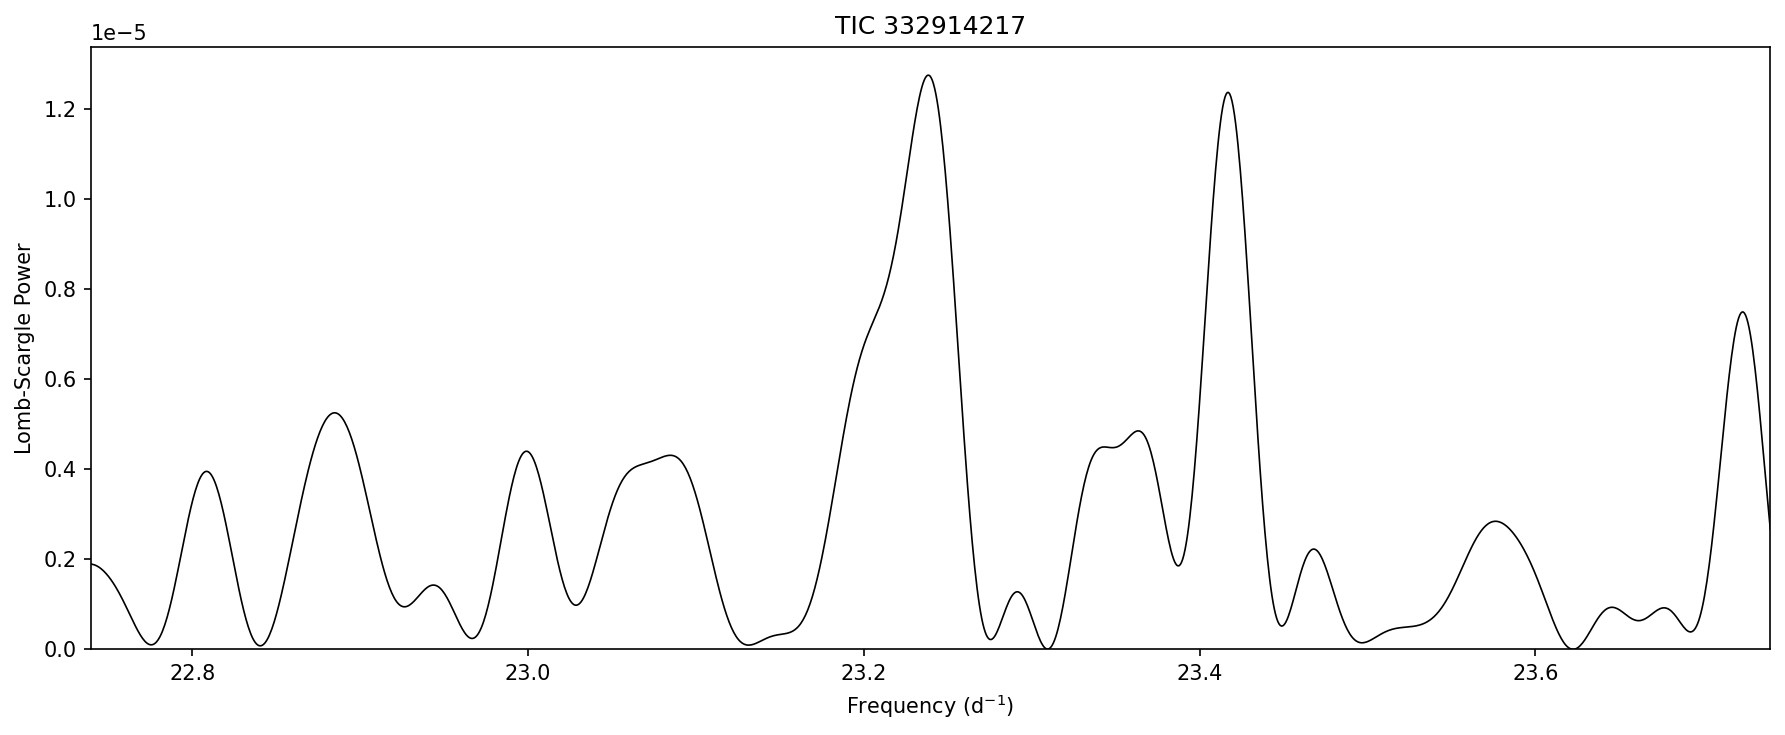

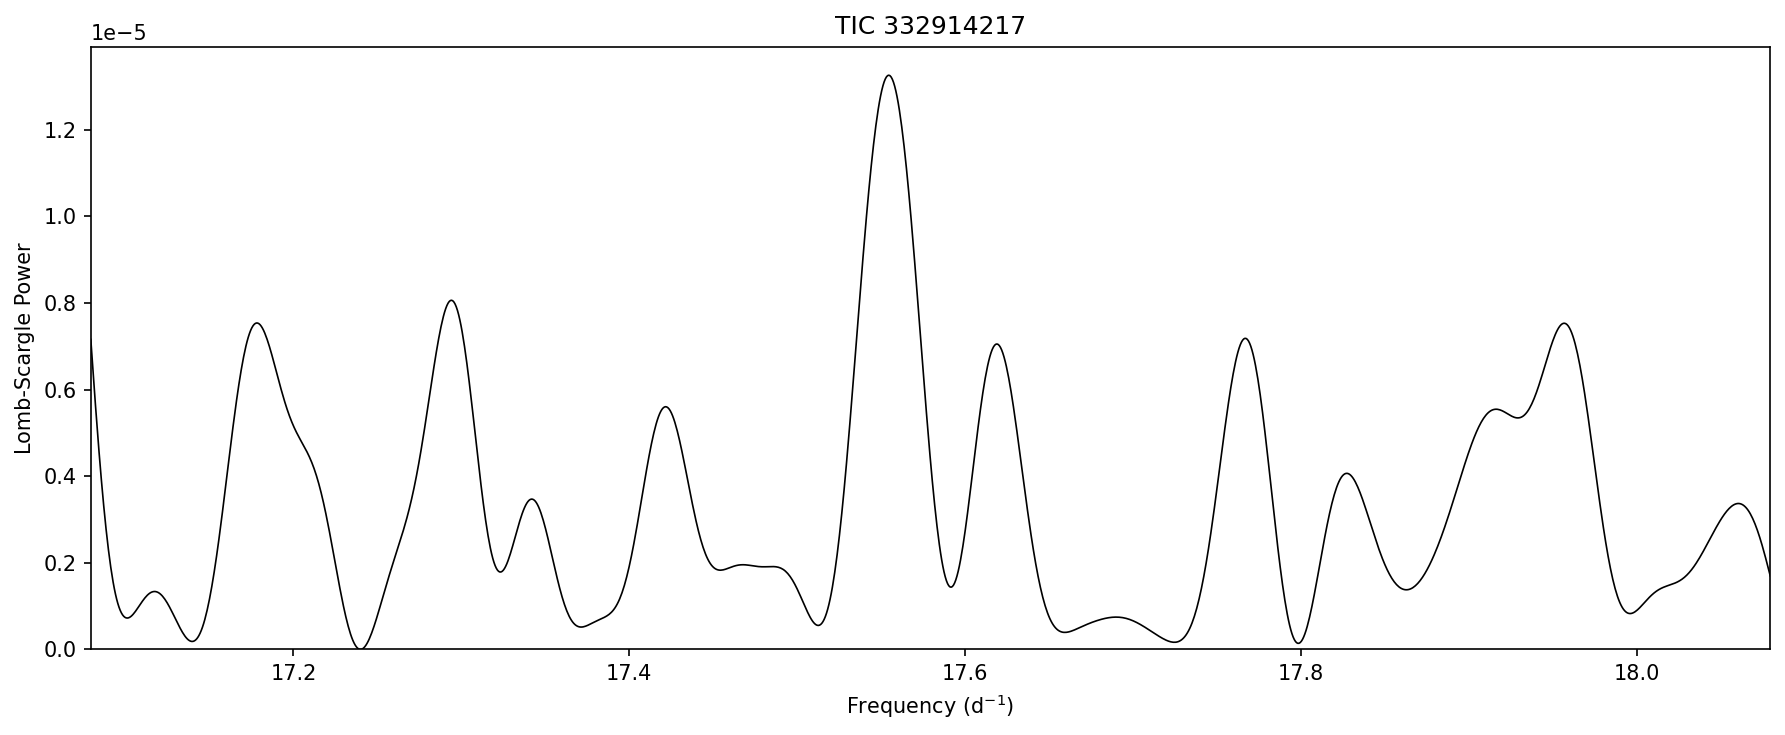

In [68]:
for freq in freqs:

    frequency = np.linspace(5, 75, 100000)
    ls = LombScargle(time, flux)
    power = ls.power(frequency)
    mask = (frequency >= freq - 0.5) & (frequency <= freq + 0.5)
    ymax = np.max(power[mask])
    
    plt.figure(figsize=(12,5))
    plt.plot(frequency, power, color="black", lw=0.8)
    
    plt.xlabel("Frequency (d$^{-1}$)")
    plt.ylabel("Lomb-Scargle Power")
    plt.title(target)
    plt.xlim(freq - 0.5, freq + 0.5)
    plt.ylim(0, ymax * 1.05)
    plt.tight_layout()
    plt.show()